Step 1 — Generate Behavioral Dataset

In [1]:
import numpy as np
import pandas as pd

n = 4000

behavior = pd.DataFrame({

"typing_speed": np.random.normal(45,10,n),

"mouse_movement": np.random.normal(300,80,n),

"click_frequency": np.random.normal(25,8,n),

"session_time": np.random.normal(15,5,n),

"login_interval": np.random.normal(12,3,n)

})

# inject anomalies
anomaly_index = np.random.choice(n,200)

behavior.loc[anomaly_index,"typing_speed"] *= 3
behavior.loc[anomaly_index,"mouse_movement"] *= 0.2

behavior.head()

,typing_speed,mouse_movement,click_frequency,session_time,login_interval
0,44.194240,225.797433,21.250592,20.291477,7.906344
1,47.268485,270.102181,31.030917,12.596400,17.158805
2,29.243827,193.413873,12.187704,22.649197,14.753591
3,37.862520,139.697952,29.405504,12.437644,13.994317
4,51.657514,263.378510,25.264275,24.375169,5.251814


# Step 2 — Isolation Forest Anomaly Detection

In [2]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05)

behavior["anomaly"] = model.fit_predict(behavior)

# convert labels
behavior["anomaly"] = behavior["anomaly"].map({
1:0,
-1:1
})

behavior.head()

,typing_speed,mouse_movement,click_frequency,session_time,login_interval,anomaly
0,44.194240,225.797433,21.250592,20.291477,7.906344,0
1,47.268485,270.102181,31.030917,12.596400,17.158805,0
2,29.243827,193.413873,12.187704,22.649197,14.753591,0
3,37.862520,139.697952,29.405504,12.437644,13.994317,0
4,51.657514,263.378510,25.264275,24.375169,5.251814,0


# Step 3 — Visualize Fraud Behavior

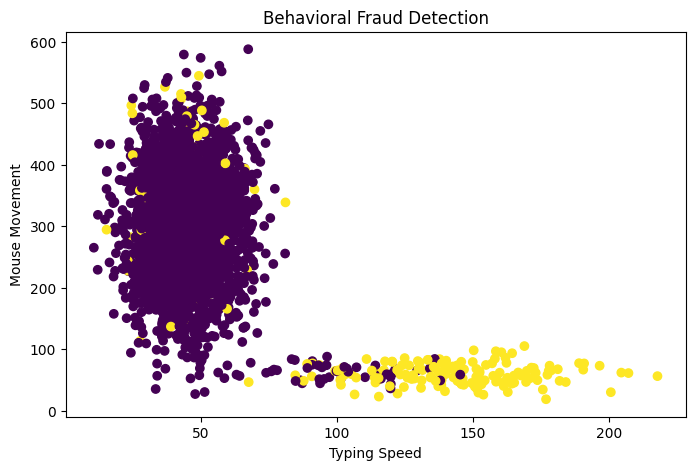

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
behavior["typing_speed"],
behavior["mouse_movement"],
c=behavior["anomaly"]
)

plt.xlabel("Typing Speed")

plt.ylabel("Mouse Movement")

plt.title("Behavioral Fraud Detection")

plt.show()